<a href="https://colab.research.google.com/github/katbee1/Data-analytics/blob/main/Capstone%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Capstone Project**
- Do some types of cuisines recieve worse inspection scores than others?
- What are the most common reasons restaurants recieve poor inspection grades?

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
#load dataset
URL = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=300000"

df = pd.read_csv(URL)


In [23]:
df

,camis,dba,boro,building,street,zipcode,phone,cuisine_description,inspection_date,action,...,inspection_type,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,location
0,50184964,GT Y BRONX LLC,Bronx,28,EAST 167 STREET,10452.0,3476562442,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.835831,-73.921630,204.0,16.0,19700.0,2003027.0,2.024960e+09,BX63,POINT (-73.921630029941 40.835830910522)
1,50143076,CHASE AD JFK,Queens,NaN,TERMINAL 4,11430.0,9173996937,Continental,2024-02-07T00:00:00.000,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50159201,NOFLEX,Manhattan,286,5 AVENUE,10001.0,2123811280,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.746117,-73.986261,105.0,4.0,7600.0,1015786.0,1.008320e+09,MN17,POINT (-73.986260669794 40.746117206418)
3,50181083,LIRA OPCO LLC,Brooklyn,2164,86 STREET,11214.0,7182651130,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.602319,-73.994443,311.0,47.0,29000.0,3167062.0,3.063800e+09,BK28,POINT (-73.994443406626 40.602319101157)
4,50175841,LUCKY CITY INC,Staten Island,201,NEW DORP LANE,10306.0,9178686860,NaN,1900-01-01T00:00:00.000,NaN,...,NaN,40.573011,-74.114513,502.0,50.0,12200.0,5052593.0,5.036370e+09,SI45,POINT (-74.11451334612 40.573010734274)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296744,50109442,BOMBAY MASALA INDIAN DINING,Brooklyn,7205,3 AVENUE,11209.0,7183335395,Indian,2024-09-18T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.633384,-74.026989,310.0,43.0,6600.0,3147331.0,3.059080e+09,BK31,POINT (-74.026988912857 40.633384273684)
296745,50125712,PLAYA BOWLS,Brooklyn,181,BEDFORD AVENUE,11211.0,6465587701,Jewish/Kosher,2023-05-31T00:00:00.000,Violations were cited in the following area(s).,...,Administrative Miscellaneous / Re-inspection,40.717952,-73.957577,301.0,33.0,55300.0,3061938.0,3.023200e+09,BK73,POINT (-73.957576573287 40.717951639087)
296746,50038206,PICKLER & CO,Manhattan,216,EAST 45 STREET,10017.0,4129521977,American,2024-11-20T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.752428,-73.972457,106.0,4.0,9000.0,1037579.0,1.013180e+09,MN19,POINT (-73.972457367894 40.752427673935)
296747,50106015,EMILIO'S ORIGINAL GOURMET PIZZA,Bronx,1015,ALLERTON AVENUE,10469.0,3478604225,Pizza,2025-07-23T00:00:00.000,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.865490,-73.858339,211.0,13.0,34400.0,2053873.0,2.045180e+09,BX31,POINT (-73.858338655436 40.865490313228)


In [24]:
#Convert inspection_date to datetime
df['inspection_date'] = pd.to_datetime(df['inspection_date'], errors='coerce')

In [25]:
#Filter to 2023-2025 dates
df = df.loc[(df['inspection_date'] >= '2023-01-01') & (df['inspection_date'] <= '2025-12-31')]

In [26]:
#Remove rows with missing data
df = df.dropna(subset=['cuisine_description','score','grade'])

In [27]:
df['grade'].value_counts()

,count
grade,
A,78978
B,16401
C,12117
N,5890
Z,2008
P,699


In [28]:
df_c = df.loc[df['grade'] =='C']
df_c.shape

(12117, 27)

In [29]:
def average_score_by_cuisine(data):
  return data.groupby('cuisine_description')['score'].mean().sort_values(ascending=False)

In [30]:
avg_scores = average_score_by_cuisine(df_c)
avg_scores.head(10)

,score
cuisine_description,
Iranian,61.000000
Barbecue,60.909091
Sandwiches/Salads/Mixed Buffet,51.918919
Other,50.733333
Ethiopian,50.000000
Australian,49.722222
Fruits/Vegetables,48.000000
Hotdogs/Pretzels,47.000000
Moroccan,47.000000


/tmp/ipykernel_29746/2372652094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.values[:10],y=avg_scores.index[:10],palette='YlGnBu_r')


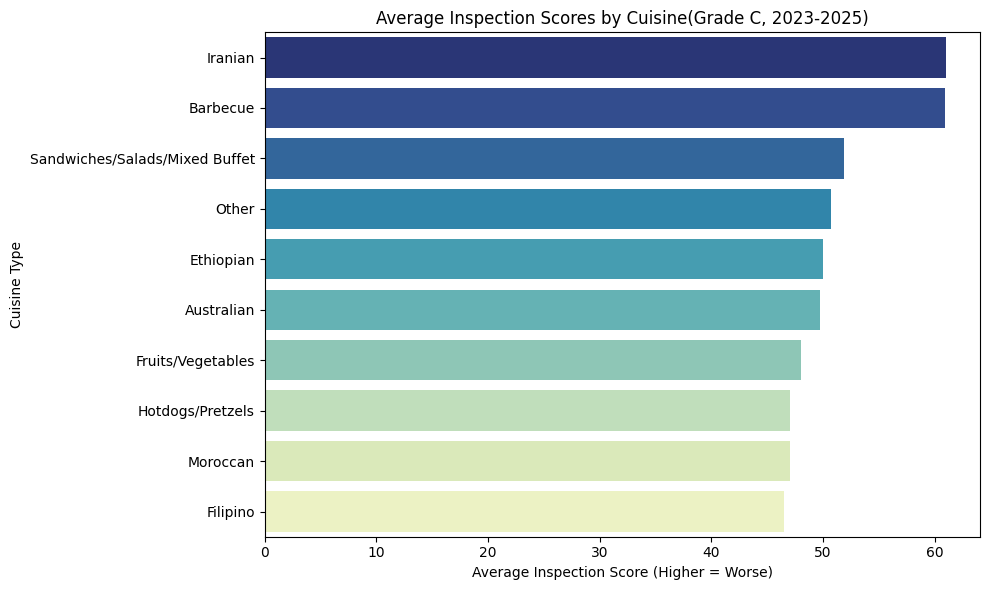

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(x=avg_scores.values[:10],y=avg_scores.index[:10],palette='YlGnBu_r')

plt.title('Average Inspection Scores by Cuisine(Grade C, 2023-2025)')
plt.xlabel('Average Inspection Score (Higher = Worse)')
plt.ylabel('Cuisine Type')

plt.tight_layout()
plt.show()


In [32]:
df_c['score'].describe()

,score
count,12117.000000
mean,41.893125
std,14.049700
min,0.000000
25%,33.000000
50%,40.000000
75%,49.000000
max,154.000000


In [33]:
grade_c_counts = (df_c['cuisine_description'].value_counts().head(10))

grade_c_counts

,count
cuisine_description,
Chinese,1755
American,1443
Pizza,796
Latin American,786
Caribbean,752
Coffee/Tea,620
Mexican,524
Bakery Products/Desserts,442
Japanese,407


/tmp/ipykernel_29746/3916419606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_c_counts.values,y=grade_c_counts.index,palette='YlGnBu_r')


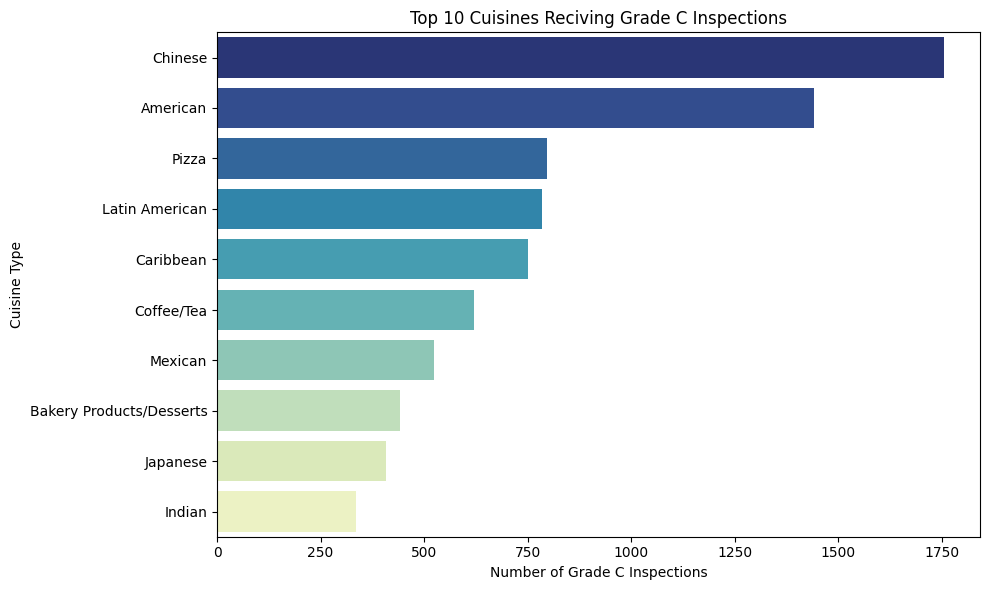

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(x=grade_c_counts.values,y=grade_c_counts.index,palette='YlGnBu_r')

plt.title('Top 10 Cuisines Reciving Grade C Inspections')
plt.xlabel('Number of Grade C Inspections')
plt.ylabel('Cuisine Type')

plt.tight_layout()
plt.show()


In [35]:
#Most common reason for Grade C
top_violations = (df_c['violation_description'].value_counts().head(5))

top_violations.to_frame(name='count').style.background_gradient(cmap='Blues')



,count
violation_description,
"Establishment is not free of harborage or conditions conducive to rodents, insects or other pests.",1354
"Non-food contact surface or equipment made of unacceptable material, not kept clean, or not properly sealed, raised, spaced or movable to allow accessibility for cleaning on all sides, above and underneath the unit.",1061
Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F; intact raw eggs held above 45 °F; or reduced oxygen packaged (ROP) TCS foods held above required temperatures except during active necessary preparation.,953
Hot TCS food item not held at or above 140 °F.,758
Evidence of mice or live mice in establishment's food or non-food areas.,735


/tmp/ipykernel_29746/2593407830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_violations.values,y=top_violations.index,palette='YlGnBu_r')
/tmp/ipykernel_29746/2593407830.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


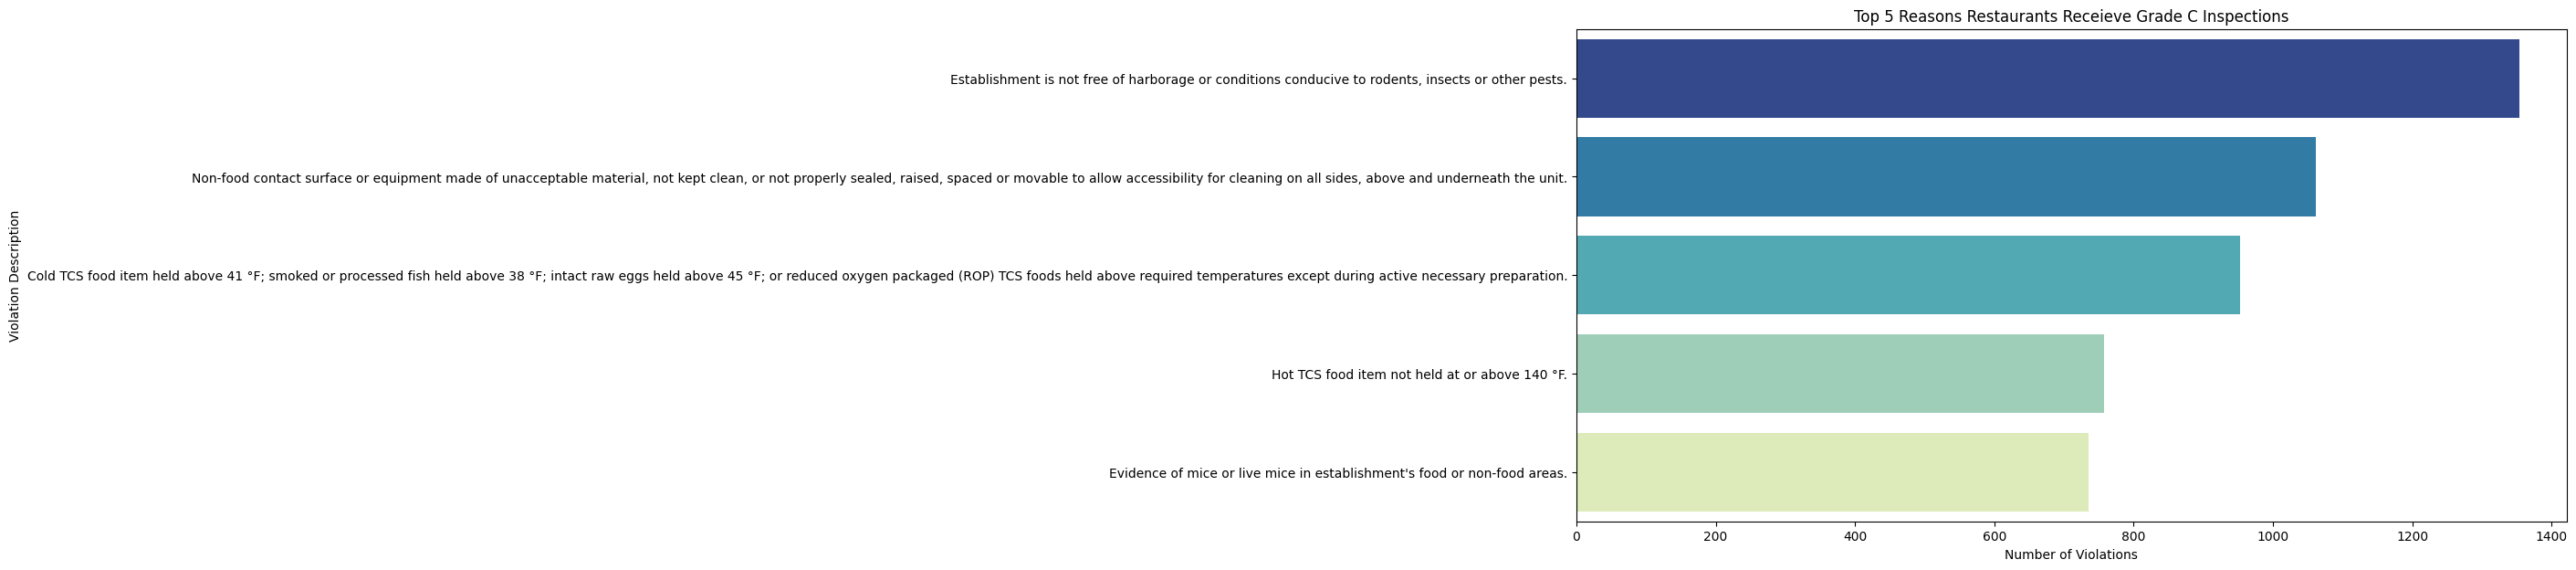

In [36]:
plt.figure(figsize=(14,7))

sns.barplot(x=top_violations.values,y=top_violations.index,palette='YlGnBu_r')

plt.title('Top 5 Reasons Restaurants Receieve Grade C Inspections')
plt.xlabel('Number of Violations')
plt.ylabel('Violation Description')

plt.tight_layout()
plt.show()